In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('✅ PyTorch version:', torch.__version__)
print('✅ Imports OK')

✅ PyTorch version: 2.10.0+cu128
✅ Imports OK


In [2]:
caminho = '/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv'
df = pd.read_csv(caminho)

print('Shape:', df.shape)
print('\nColunas:', list(df.columns))
print('\nDistribuição do Target:')
print(df['Burnout_Risk_Level'].value_counts())

Shape: (50000, 16)

Colunas: ['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']

Distribuição do Target:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


In [3]:
# Features derivadas
df['AI_Ratio']              = df['Weekly_GenAI_Hours'] / (df['Traditional_Study_Hours'] + 1)
df['AI_Dependency_x_Ratio'] = df['Perceived_AI_Dependency'] * df['AI_Ratio']

COLUNAS_NUMERICAS = [
    'Traditional_Study_Hours',
    'Weekly_GenAI_Hours',
    'AI_Ratio',
    'AI_Dependency_x_Ratio',
    'Perceived_AI_Dependency',
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Anxiety_Level_During_Exams',
    'Skill_Retention_Score',
    'Tool_Diversity',
]

COLUNAS_CATEGORICAS = [
    'Major_Category',
    'Year_of_Study',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Institutional_Policy',
]

TARGET = 'Burnout_Risk_Level'

cols_num = [c for c in COLUNAS_NUMERICAS if c in df.columns]
cols_cat = [c for c in COLUNAS_CATEGORICAS if c in df.columns]

print('Features numéricas:', cols_num)
print('Features categóricas:', cols_cat)

X_raw = df[cols_num + cols_cat].copy()
y_raw = df[TARGET].copy()

print(f'\nShape X: {X_raw.shape}')

Features numéricas: ['Traditional_Study_Hours', 'Weekly_GenAI_Hours', 'AI_Ratio', 'AI_Dependency_x_Ratio', 'Perceived_AI_Dependency', 'Pre_Semester_GPA', 'Post_Semester_GPA', 'Anxiety_Level_During_Exams', 'Skill_Retention_Score', 'Tool_Diversity']
Features categóricas: ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy']

Shape X: (50000, 15)


In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
print('Classes:', le.classes_)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), cols_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_cat)
])

X_processed = preprocessor.fit_transform(X_raw)
print(f'Shape após encoding: {X_processed.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_inicial, X_feedback, y_inicial, y_feedback = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

print(f'\nTreino inicial: {X_inicial.shape[0]} amostras')
print(f'Dados de feedback: {X_feedback.shape[0]} amostras')
print(f'Teste final: {X_test.shape[0]} amostras')

Classes: ['High' 'Low' 'Medium']
Shape após encoding: (50000, 31)

Treino inicial: 32000 amostras
Dados de feedback: 8000 amostras
Teste final: 10000 amostras


In [5]:
def numpy_para_tensores(X, y):
    X_t = torch.FloatTensor(X)
    y_t = torch.LongTensor(y)
    return TensorDataset(X_t, y_t)

dataset_inicial  = numpy_para_tensores(X_inicial, y_inicial)
dataset_feedback = numpy_para_tensores(X_feedback, y_feedback)
dataset_teste    = numpy_para_tensores(X_test, y_test)

loader_inicial  = DataLoader(dataset_inicial,  batch_size=64, shuffle=True)
loader_feedback = DataLoader(dataset_feedback, batch_size=64, shuffle=True)
loader_teste    = DataLoader(dataset_teste,    batch_size=64, shuffle=False)

INPUT_DIM = X_processed.shape[1]
print(f'✅ Tensores criados! Dimensão de entrada: {INPUT_DIM}')

✅ Tensores criados! Dimensão de entrada: 31


In [6]:
class RedeNeuralBurnout(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super(RedeNeuralBurnout, self).__init__()
        
        self.rede = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.rede(x)


modelo = RedeNeuralBurnout(INPUT_DIM)
print(modelo)
total_params = sum(p.numel() for p in modelo.parameters())
print(f'\nTotal de parâmetros: {total_params:,}')

RedeNeuralBurnout(
  (rede): Sequential(
    (0): Linear(in_features=31, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total de parâmetros: 12,931


In [7]:
criterio   = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.001)


def treinar_uma_epoca(modelo, loader, otimizador, criterio):
    modelo.train()
    perda_total = 0
    corretos = 0
    total = 0
    
    for X_batch, y_batch in loader:
        otimizador.zero_grad()
        saidas = modelo(X_batch)
        perda  = criterio(saidas, y_batch)
        perda.backward()
        otimizador.step()
        
        perda_total += perda.item()
        _, previstos = torch.max(saidas, 1)
        corretos += (previstos == y_batch).sum().item()
        total    += y_batch.size(0)
    
    return perda_total / len(loader), corretos / total


def avaliar(modelo, loader):
    modelo.eval()
    corretos = 0
    total = 0
    todas_previsoes = []
    todos_reais     = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            saidas = modelo(X_batch)
            _, previstos = torch.max(saidas, 1)
            corretos += (previstos == y_batch).sum().item()
            total    += y_batch.size(0)
            todas_previsoes.extend(previstos.numpy())
            todos_reais.extend(y_batch.numpy())
    
    return corretos / total, todas_previsoes, todos_reais


print('✅ Funções prontas!')

✅ Funções prontas!


In [8]:
print('🚀 Fase 1: Treino inicial...\n')

EPOCAS = 30
historico_perda    = []
historico_acuracia = []

for epoca in range(EPOCAS):
    perda, acc_treino = treinar_uma_epoca(modelo, loader_inicial, otimizador, criterio)
    historico_perda.append(perda)
    historico_acuracia.append(acc_treino)
    
    if (epoca + 1) % 5 == 0:
        print(f'  Época {epoca+1:02d}/{EPOCAS} | Perda: {perda:.4f} | Acurácia treino: {acc_treino:.4f}')

acc_inicial, _, _ = avaliar(modelo, loader_teste)
print(f'\n📊 Acurácia no TESTE após treino inicial: {acc_inicial:.4f} ({acc_inicial*100:.1f}%)')

🚀 Fase 1: Treino inicial...

  Época 05/30 | Perda: 0.9221 | Acurácia treino: 0.5302
  Época 10/30 | Perda: 0.9162 | Acurácia treino: 0.5364
  Época 15/30 | Perda: 0.9137 | Acurácia treino: 0.5400
  Época 20/30 | Perda: 0.9131 | Acurácia treino: 0.5404
  Época 25/30 | Perda: 0.9081 | Acurácia treino: 0.5428
  Época 30/30 | Perda: 0.9064 | Acurácia treino: 0.5413

📊 Acurácia no TESTE após treino inicial: 0.5291 (52.9%)


In [9]:
print('🔄 Fase 2: Loop de Feedback\n')
print('Simulando chegada de novos dados em 3 rodadas...\n')

tamanho_lote = len(X_feedback) // 3
acuracias_feedback = [acc_inicial]

for rodada in range(3):
    inicio = rodada * tamanho_lote
    fim    = inicio + tamanho_lote if rodada < 2 else len(X_feedback)
    
    X_lote = X_feedback[inicio:fim]
    y_lote = y_feedback[inicio:fim]
    
    dataset_lote = numpy_para_tensores(X_lote, y_lote)
    loader_lote  = DataLoader(dataset_lote, batch_size=32, shuffle=True)
    
    for _ in range(10):
        treinar_uma_epoca(modelo, loader_lote, otimizador, criterio)
    
    acc_atual, _, _ = avaliar(modelo, loader_teste)
    acuracias_feedback.append(acc_atual)
    
    print(f'  Rodada {rodada+1}/3 | Novos dados: {len(X_lote)} amostras '
          f'| Acurácia pós-feedback: {acc_atual:.4f} ({acc_atual*100:.1f}%)')

print(f'\n✅ Acurácia final após loop de feedback: {acuracias_feedback[-1]:.4f}')

🔄 Fase 2: Loop de Feedback

Simulando chegada de novos dados em 3 rodadas...

  Rodada 1/3 | Novos dados: 2666 amostras | Acurácia pós-feedback: 0.5257 (52.6%)
  Rodada 2/3 | Novos dados: 2666 amostras | Acurácia pós-feedback: 0.5230 (52.3%)
  Rodada 3/3 | Novos dados: 2668 amostras | Acurácia pós-feedback: 0.5259 (52.6%)

✅ Acurácia final após loop de feedback: 0.5259


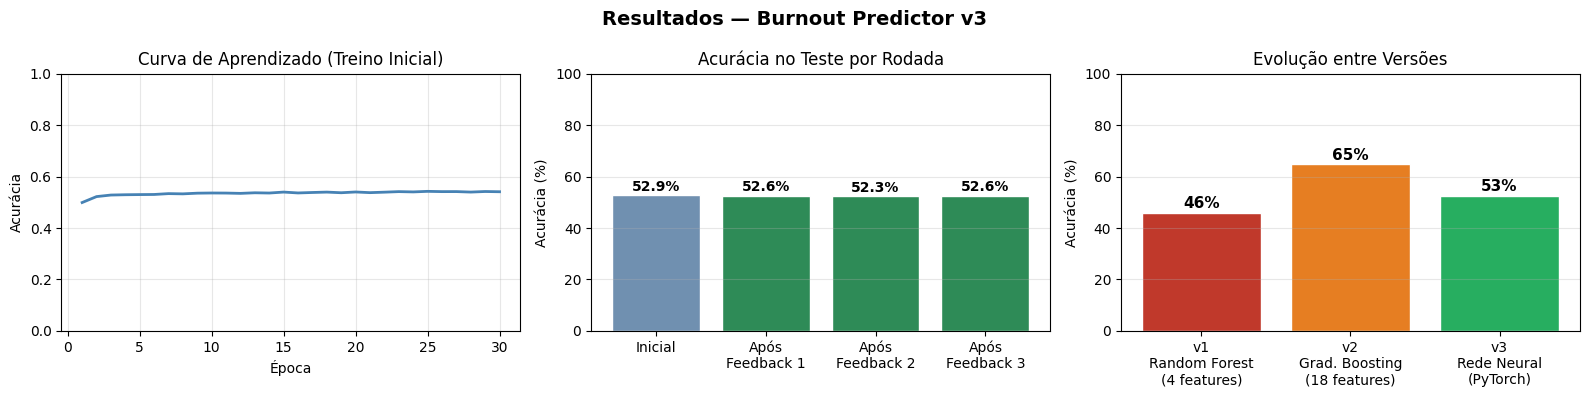

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Resultados — Burnout Predictor v3', fontsize=14, fontweight='bold')

# Curva de aprendizado
axes[0].plot(range(1, EPOCAS+1), historico_acuracia, color='steelblue', linewidth=2)
axes[0].set_title('Curva de Aprendizado (Treino Inicial)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Evolução do feedback
rotulos = ['Inicial', 'Após\nFeedback 1', 'Após\nFeedback 2', 'Após\nFeedback 3']
cores   = ['#7090b0' if i == 0 else '#2e8b57' for i in range(4)]
bars = axes[1].bar(rotulos, [a*100 for a in acuracias_feedback], color=cores, edgecolor='white')
for bar, val in zip(bars, acuracias_feedback):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_title('Acurácia no Teste por Rodada')
axes[1].set_ylabel('Acurácia (%)')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

# Comparação entre versões
versoes          = ['v1\nRandom Forest\n(4 features)', 'v2\nGrad. Boosting\n(18 features)', 'v3\nRede Neural\n(PyTorch)']
acuracias_versoes = [46, 65, acuracias_feedback[-1]*100]
cores_versoes    = ['#c0392b', '#e67e22', '#27ae60']
bars2 = axes[2].bar(versoes, acuracias_versoes, color=cores_versoes, edgecolor='white')
for bar, val in zip(bars2, acuracias_versoes):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[2].set_title('Evolução entre Versões')
axes[2].set_ylabel('Acurácia (%)')
axes[2].set_ylim(0, 100)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('resultados_v3.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
_, previsoes_finais, reais_finais = avaliar(modelo, loader_teste)

print('📊 Relatório Final de Classificação — v3 (após feedback):')
print(classification_report(reais_finais, previsoes_finais, target_names=le.classes_))

print('\n📈 Resumo da Evolução:')
print(f'  v1 (Random Forest, 4 features):       ~46%')
print(f'  v2 (Gradient Boosting, 18 features):  ~65%')
print(f'  v3 (Rede Neural + Feedback):           {acuracias_feedback[-1]*100:.1f}%')

📊 Relatório Final de Classificação — v3 (após feedback):
              precision    recall  f1-score   support

        High       0.66      0.44      0.53      2497
         Low       0.53      0.49      0.51      3274
      Medium       0.48      0.60      0.54      4229

    accuracy                           0.53     10000
   macro avg       0.56      0.51      0.53     10000
weighted avg       0.54      0.53      0.53     10000


📈 Resumo da Evolução:
  v1 (Random Forest, 4 features):       ~46%
  v2 (Gradient Boosting, 18 features):  ~65%
  v3 (Rede Neural + Feedback):           52.6%


In [12]:
import joblib, json

torch.save({
    'model_state_dict': modelo.state_dict(),
    'input_dim': INPUT_DIM,
    'num_classes': 3,
}, 'modelo_burnout_v3.pth')

joblib.dump(preprocessor, 'preprocessor_v3.pkl')
joblib.dump(le, 'label_encoder_v3.pkl')

meta = {
    'colunas_numericas': cols_num,
    'colunas_categoricas': cols_cat,
    'classes': list(le.classes_),
    'input_dim': INPUT_DIM,
    'versao': '3.0',
    'acuracia_final': round(float(acuracias_feedback[-1]), 4)
}
with open('model_metadata_v3.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ Arquivos salvos:')
print('   modelo_burnout_v3.pth')
print('   preprocessor_v3.pkl')
print('   label_encoder_v3.pkl')
print('   model_metadata_v3.json')

✅ Arquivos salvos:
   modelo_burnout_v3.pth
   preprocessor_v3.pkl
   label_encoder_v3.pkl
   model_metadata_v3.json
